Now lets see how to build these models simply

In [27]:
# Import required modules

import os

from ultralytics import YOLO
from IPython.display import Image , display

os.environ["OPENCV_FFMPEG_CAPTURE_OPTIONS"] = "video_codec;h264"


In [2]:
model = YOLO("yolov8n.pt")

In [4]:
results = model.train(
    data = "./weapon-detection/data.yaml",
    epochs = 50,
    workers = 4,
    batch = 4,
    imgsz = 448,
    lr0 = 0.001,
    lrf = 0.5,
    cos_lr = False,
    val = False
)

#note that I am passing this argument because ultralytics defaults these to 640px but for suppose
#you have an image of size 1280 and the default argument this image is compressed automatically to 640px which can cause the
#loss of spacial information to your model similar for an image of smaller dimension

# This train train follows linear decay with initial lr to be 0.001 and final to be 0.0005

Ultralytics 8.4.60 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 5806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./weapon-detection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=448, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.5, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

One important parameter in object detection is confidence 

A lower confidence can lead to more false positives
A higher confidence can lead to more false negatives

**NOTE:** Selecting a good confidence score is similar to maximising F1 score wrt to confidence

simply,
$$c_{best} = \arg\max_{c} \text{F1}(c)$$
$$\text{Where c is confidence}$$



In [6]:
# these are the that we can check to figure out the above problem
results.curves

['Precision-Recall(B)',
 'F1-Confidence(B)',
 'Precision-Confidence(B)',
 'Recall-Confidence(B)']

In [ ]:
# to access these plots you can check in runs/detect/{respected training run} in this case train run is train - 2

In [8]:
os.listdir("./runs/detect/train-2/")

['BoxR_curve.png',
 'confusion_matrix_normalized.png',
 'confusion_matrix.png',
 'val_batch2_pred.jpg',
 'train_batch2.jpg',
 'val_batch2_labels.jpg',
 'val_batch0_labels.jpg',
 'weights',
 'train_batch50041.jpg',
 'results.png',
 'val_batch1_pred.jpg',
 'results.csv',
 'val_batch0_pred.jpg',
 'train_batch0.jpg',
 'BoxP_curve.png',
 'train_batch50042.jpg',
 'labels.jpg',
 'args.yaml',
 'BoxF1_curve.png',
 'train_batch1.jpg',
 'train_batch50040.jpg',
 'BoxPR_curve.png',
 'val_batch1_labels.jpg']

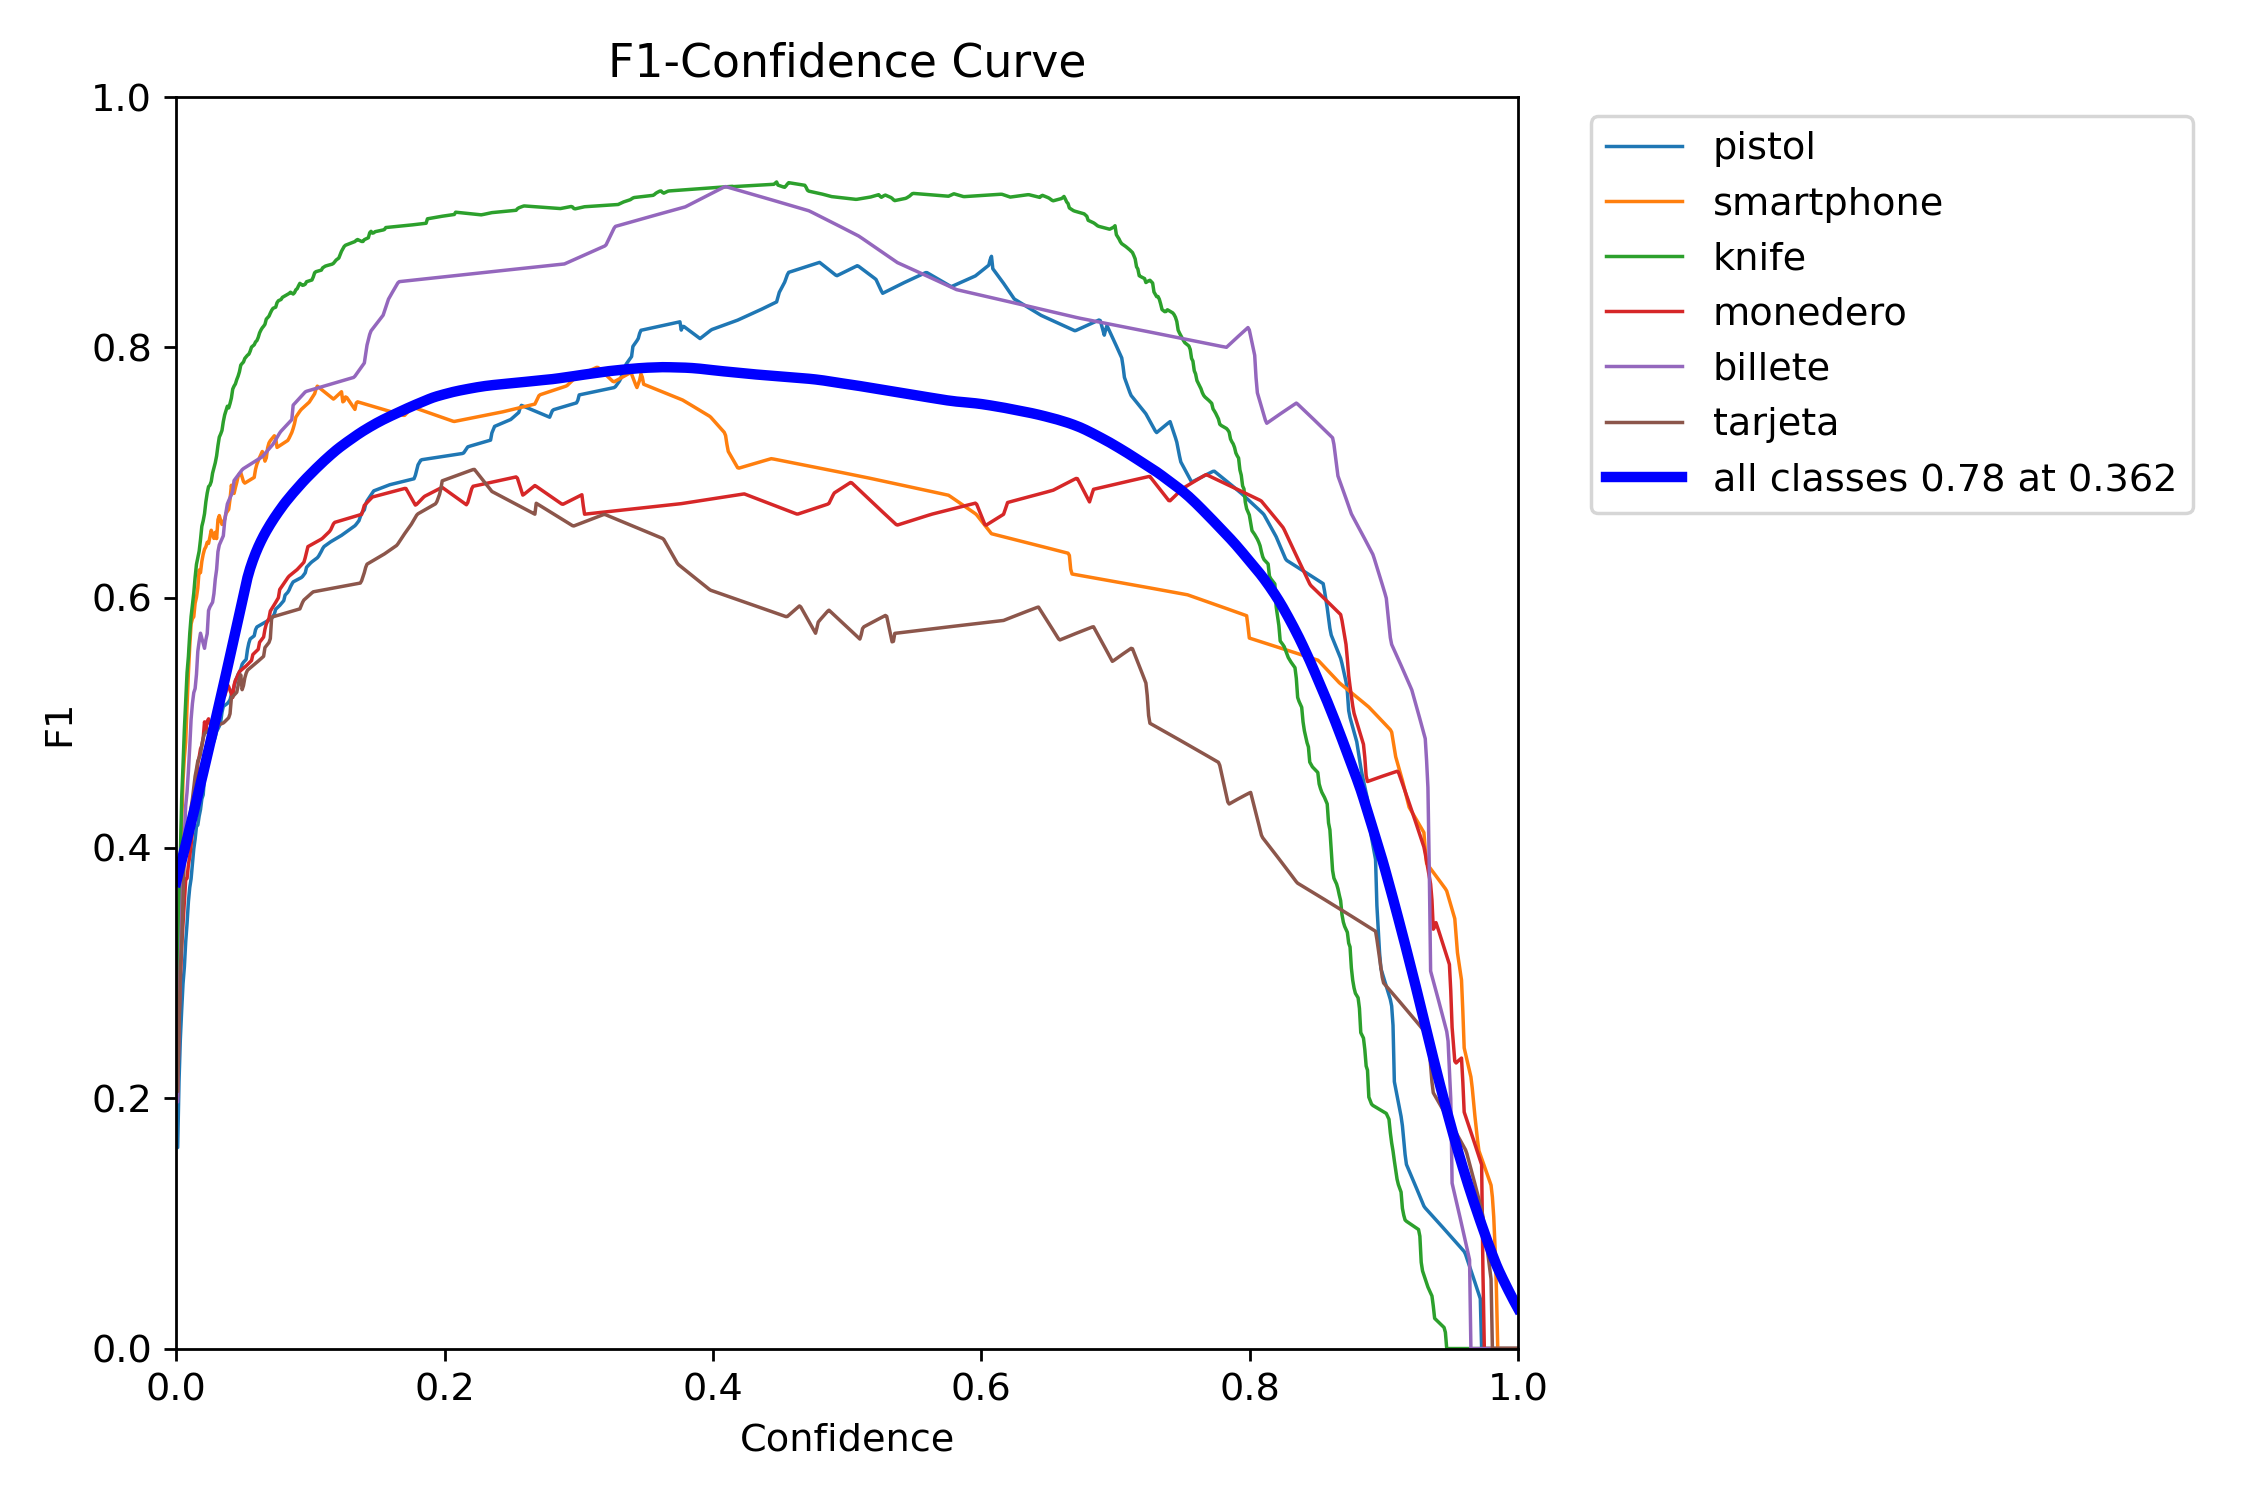

In [11]:
#lets check the f1 plot vs confidence

display(Image(filename = "./runs/detect/train-2/BoxF1_curve.png"))

The most suitable curve is given by the dark blue line 

For a task like this you might need a confidence threshold slighly lower because more false negatives are better than false positives

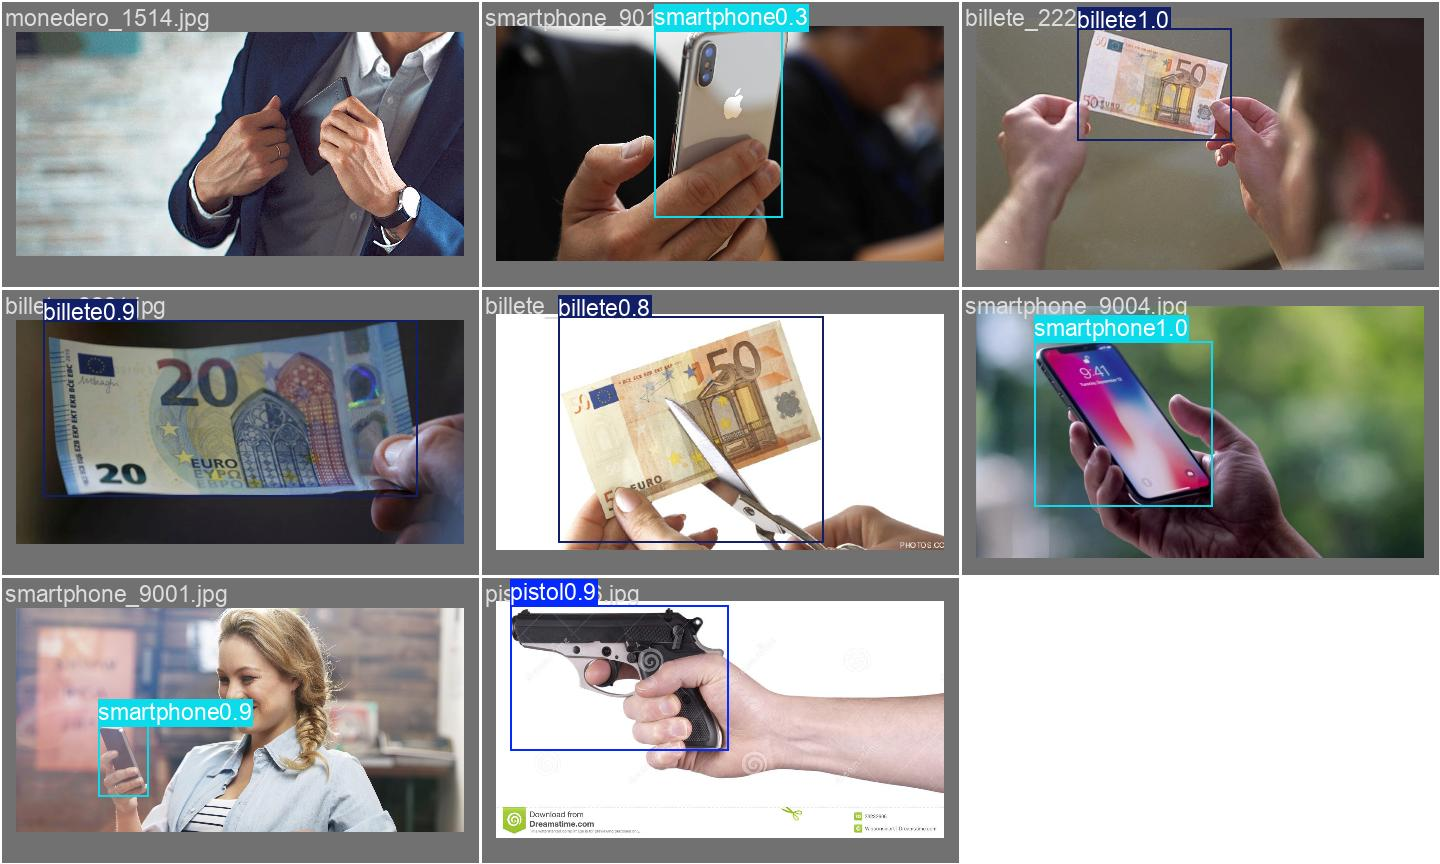

In [12]:
# An example prediction can be seen in such images "val_batch0_pred.jpg"

display(Image(filename = "./runs/detect/train-2/val_batch0_pred.jpg"))